<a href="https://colab.research.google.com/github/fabianoseller/-Estrutura-de-um-Projeto-/blob/main/Frameworks_para_Deep_Learning_PyTorch_%26_Keras_FINAL_CONTDOWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pós-Graduação em Estatística para Ciência de Dados (PUC Minas)
## Disciplina: Redes Neurais e Deep Learning
### Lista de Exercícios 3: Frameworks para Deep Learning (PyTorch & Keras)
**O Modelo como seu "Pair Programmer"**

**Aluno:** Fabiano Antunes  
**Data:** 08 de abril de 2026  
**Status:** FINAL COUNTDOWN  

---

## 🎯 Objetivo da Atividade
Esta atividade utiliza a técnica de **Aprendizado Ativo via Prompting**. O foco não é apenas a geração de código, mas o domínio do fluxo de construção e validação de soluções em Deep Learning, utilizando LLMs como apoio estratégico (Pair Programming).

### Estrutura de Documentação por Exercício:
1. **Prompt Inicial:** A instrução enviada à IA.
2. **Resposta Intermediária:** O retorno do modelo.
3. **Análise Crítica:** Reflexão sobre a técnica de prompting utilizada e os conceitos de Deep Learning validados.

## Exercício 1: Manipulação de Tensores e Broadcasting
**Conceito:** Entender como o PyTorch lida com operações entre tensores de diferentes formatos.

### 🤖 Fluxo de Execução: Prompt 1 (CoT)
**Instrução:** "Tenho um tensor A de shape (32, 1, 10) e um tensor B de shape (10). Quero somá-los no PyTorch. Pense passo a passo: explique se essa operação é possível via broadcasting, descreva como as dimensões serão expandidas mentalmente pelo framework e forneça o código."

In [1]:
import torch

# Criando os tensores base para validação
tensor_a = torch.randn(32, 1, 10)
tensor_b = torch.randn(10)

print(f"Shape de A: {tensor_a.shape}")
print(f"Shape de B: {tensor_b.shape}")

# Operação de Soma (Broadcasting)
try:
    resultado = tensor_a + tensor_b
    print(f"Soma realizada com sucesso! Shape do resultado: {resultado.shape}")
except Exception as e:
    print(f"Erro na operação: {e}")

Shape de A: torch.Size([32, 1, 10])
Shape de B: torch.Size([10])
Soma realizada com sucesso! Shape do resultado: torch.Size([32, 1, 10])


### 🤖 Fluxo de Execução: Prompt 2 (Reflexão)
**Instrução:** "Agora, critique a explicação anterior. Ela deixou claro o que acontece com a dimensão do batch (32)? O código funcionaria se o tensor B fosse (32, 1) em vez de (10)? Corrija a explicação para incluir esses cenários de erro comuns."

---

### 🎓 Análise Crítica do Aluno
*Escreva aqui como a técnica de "pensar passo a passo" ajudou a visualizar que o PyTorch alinha as dimensões da direita para a esquerda e 'estica' as dimensões unitárias ou inexistentes.*

### 🤖 Fluxo de Execução: Prompt 2 (Reflexão)
**Instrução:** "Agora, critique a explicação anterior. Ela deixou claro o que acontece com a dimensão do batch (32)? O código funcionaria se o tensor B fosse (32, 1) em vez de (10)? Corrija a explicação para incluir esses cenários de erro comuns."

---

### 🎓 Análise Crítica do Aluno
Explicação técnica rápida para sua análise:
O PyTorch olha para as dimensões do fim para o começo:

Dimensão 3: A tem 10, B tem 10. (OK)

Dimensão 2: A tem 1, B não tem nada. O PyTorch assume 1. (OK)

Dimensão 1: A tem 32, B não tem nada. O PyTorch assume 1 e "expande" para 32. (OK)

Por isso o resultado final é (32, 1, 10). Se B fosse (32, 1), a última dimensão de B (1) tentaria somar com a última de A (10), o que daria erro se não fossem compatíveis!

## Exercício 2: Arquitetura de Redes Neurais (O "De-Para" Keras/PyTorch)
**Conceito:** Traduzir a simplicidade do Keras para a estrutura de classes e controle fino do PyTorch.

### 🤖 Fluxo de Execução: Prompt 1 (Geração Múltipla)
**Instrução:** "Crie uma rede neural para o MNIST (dígitos manuscritos). Gere três caminhos de implementação diferentes no PyTorch no mesmo chat:
* **Caminho A:** Usando `nn.Sequential`.
* **Caminho B:** Usando uma classe com `nn.Module` e `nn.Linear`.
* **Caminho C:** Uma versão otimizada usando `nn.Flatten` e Dropout."

In [2]:
import torch
import torch.nn as nn

# Exemplo do Caminho B (A forma mais comum em produção/pesquisa)
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


### 🤖 Fluxo de Execução: Prompt 2 (Votação/Consistência)
**Instrução:** "Compare as três versões. Qual delas é a mais 'Pythonica' e escalável para grandes projetos? Quais componentes são idênticos em todas as versões (como a função de ativação e a entrada)?"

---

### 🎓 Análise Crítica do Aluno
Diferente do Keras, onde o modelo é muitas vezes uma "caixa preta" sequencial, no PyTorch o método forward é puro Python. Isso significa que você pode colocar prints, if/else ou loops dentro da passagem de dados, o que é um divisor de águas para depurar pipelines de dados complexos (como os que você lida no Estado).

## Exercício 3: Otimizadores e o Ciclo de Treinamento
**Conceito:** No PyTorch, o controle do gradiente é manual. Entender o papel do otimizador e a evolução do Adam para o AdamW é fundamental para a convergência de modelos profundos.

### 🤖 Fluxo de Execução: Prompt 1 (Query Expansion)
**Instrução:** "Quero aprender sobre o otimizador AdamW no PyTorch. Em vez de me dar apenas a definição, gere 5 termos de pesquisa ou sub-tópicos avançados que eu deveria perguntar para entender como ele melhora o Adam tradicional (ex: weight decay, taxas de aprendizado desacopladas)."

In [3]:
import torch
import torch.optim as optim

# Configuração fictícia de modelo e perda
model = torch.nn.Linear(10, 2)
criterion = torch.nn.CrossEntropyLoss()

# Implementando o AdamW
# lr: learning rate | weight_decay: penalização L2 desacoplada
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Simulação de um passo de treinamento
data = torch.randn(8, 10)
target = torch.tensor([1, 0, 1, 0, 0, 1, 0, 1])

# O Ciclo do PyTorch
optimizer.zero_grad()   # 1. Zerar gradientes
output = model(data)    # 2. Forward pass
loss = criterion(output, target) # 3. Calcular erro
loss.backward()         # 4. Backpropagation (Cálculo dos gradientes)
optimizer.step()        # 5. Atualização dos pesos

print(f"Loss: {loss.item():.4f}")

Loss: 0.8198


### 🤖 Fluxo de Execução: Prompt 2 (Ação)
**Instrução:** "Agora, use esses tópicos para explicar como implementar o AdamW em um loop de treinamento do PyTorch que inclua loss.backward() e optimizer.step()."

---

### 🎓 Análise Crítica do Aluno
*Analise aqui: Como a técnica de expandir a pergunta (Query Expansion) trouxe O segredo do AdamW está em como ele lida com a regularização. No Adam comum, o weight decay acaba sendo influenciado pelos momentos (médias móveis dos gradientes), o que pode "bagunçar" a penalização. O AdamW aplica a penalização diretamente nos pesos, o que costuma levar a uma generalização muito melhor em modelos de Deep Learning.

## Exercício 4: Debugging de Gradientes (Reflection)
**Conceito:** Um erro comum no PyTorch é esquecer de zerar os gradientes, fazendo com que eles se acumulem incorretamente entre os batches. Entender a transparência do PyTorch é a chave para o debugging eficiente.

### 🤖 Fluxo de Execução: Prompt 1 (Ação)
**Instrução:** "Escreva um código propositalmente errado de um loop de treinamento em PyTorch onde os gradientes não são zerados."

In [4]:
import torch

# Modelo simples: y = 2x
model = torch.nn.Linear(1, 1, bias=False)
with torch.no_grad():
    model.weight.fill_(1.0) # Começamos com peso 1.0

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
x = torch.tensor([[1.0]])
target = torch.tensor([[2.0]])

print("--- Iniciando Treinamento ERRADO (Sem zero_grad) ---")
for epoch in range(3):
    # optimizer.zero_grad() <--- O ERRO ESTÁ AQUI (COMENTADO)

    output = model(x)
    loss = torch.nn.functional.mse_loss(output, target)
    loss.backward()

    print(f"Época {epoch+1}:")
    print(f"  Gradiente acumulado: {model.weight.grad.item()}")

    optimizer.step()
    print(f"  Peso após o step: {model.weight.item():.4f}")

--- Iniciando Treinamento ERRADO (Sem zero_grad) ---
Época 1:
  Gradiente acumulado: -2.0
  Peso após o step: 1.2000
Época 2:
  Gradiente acumulado: -3.5999999046325684
  Peso após o step: 1.5600
Época 3:
  Gradiente acumulado: -4.479999542236328
  Peso após o step: 2.0080


### 🤖 Fluxo de Execução: Prompt 2 (Reflection)
**Instrução:** "Atue como um Depurador de Código (Debugger). Analise o código anterior, identifique o erro catastrófico e explique o que aconteceria com os pesos do modelo após 10 épocas se esse erro persistisse."

### 🤖 Fluxo de Execução: Prompt 3 (Refinamento)
**Instrução:** "Forneça a versão corrigida e adicione uma verificação (assert) ou um print que comprove que os gradientes estão sendo resetados."

---

### 🎓 Análise Crítica do Aluno
Pense no seu trabalho com dados governamentais: se você estiver rodando uma simulação pesada onde o batch size não cabe na memória, você pode usar o loss.backward() em 4 mini-batches e só depois dar o optimizer.step() e o zero_grad(). Isso se chama Gradient Accumulation. O Keras esconde isso de você; o PyTorch te dá o controle total, mas exige que você seja o "maestro" dos gradientes.

## Exercício 5: Modo de Treino vs. Modo de Avaliação
**Conceito:** No PyTorch, precisamos alternar manualmente entre `model.train()` e `model.eval()`. Isso altera o comportamento estocástico de camadas como Dropout e o cálculo de estatísticas da Batch Normalization.

### 🤖 Fluxo de Execução: Prompt 1 (CoT)
**Instrução:** "Explique para que servem os comandos model.train() e model.eval() no PyTorch. Pense passo a passo: o que acontece com uma camada de Dropout em cada um desses modos?"

In [5]:
import torch
import torch.nn as nn

# Criando um modelo simples com Dropout
model = nn.Sequential(
    nn.Linear(10, 10),
    nn.Dropout(p=0.5)
)

data = torch.ones(1, 10)

print("--- Modo de TREINO (model.train()) ---")
model.train()
print(f"Saída com Dropout ativo (alguns zeros): \n{model(data)}")

print("\n--- Modo de AVALIAÇÃO (model.eval()) ---")
model.eval()
print(f"Saída com Dropout desativado (valores escalados): \n{model(data)}")

--- Modo de TREINO (model.train()) ---
Saída com Dropout ativo (alguns zeros): 
tensor([[-0.0000, -1.9862,  0.4172,  0.6345,  1.7856, -0.0000, -1.0630, -0.0000,
         -0.0000, -0.0000]], grad_fn=<MulBackward0>)

--- Modo de AVALIAÇÃO (model.eval()) ---
Saída com Dropout desativado (valores escalados): 
tensor([[-0.1320, -0.9931,  0.2086,  0.3173,  0.8928, -0.7898, -0.5315, -1.4178,
         -1.1079, -0.2293]], grad_fn=<AddmmBackward0>)


### 🤖 Fluxo de Execução: Prompt 2 (Self-Consistency)
**Instrução:** "Peça ao modelo para gerar duas formas de realizar a inferência (validação) sem calcular gradientes: uma usando o decorator `@torch.no_grad()` e outra usando o context manager `with torch.no_grad():`."

### 🤖 Fluxo de Execução: Prompt 3 (Reflection)
**Instrução:** "Peça para o modelo criticar um código de validação que esquece de usar model.eval(), mesmo usando torch.no_grad(). Qual o impacto disso no resultado final da validação?"

---

### 🎓 Análise Crítica do Aluno
Pense na estabilidade dos dados. No seu trabalho com o TJE ou Devolve ICMS, você não quer que uma previsão mude cada vez que você roda o modelo por causa de um Dropout ativado.

model.eval() garante que a "estrutura" da rede seja determinística.

torch.no_grad() garante que você não desperdice a memória do servidor (ou do Colab) guardando informações que só servem para o treinamento.

# Exemplo pratico que vamos usar:

*https://www.kaggle.com/datasets/angelmm/healthteethsugar/data*

Problemas dentários, açúcar e gastos governamentais com saúde.
Obrigado aos dados da Gapminder

### Sobre o conjunto de dados
Se você enriquece, seus dentes podem piorar (se você consumir mais alimentos açucarados) ou melhorar (devido a melhor assistência médica ou, até mesmo, mais educação e consciência sobre saúde). Essas variáveis ​​podem ser analisadas com estes dados, baixados do Gapminder Data :

Problemas dentários por criança (12 anos, OMS)
PIB per capita (US$, ajustado pela inflação, Banco Mundial)
Gastos governamentais com saúde por pessoa (US$, OMS)
Consumo de açúcar por pessoa (g por dia, FAO) Taxa de alfabetização, total de adultos (% de pessoas com 15 anos ou mais, UNESCO)

In [9]:
import pandas as pd
import torch

# Carregando e limpando os dados (Foco no ano de 2004)
badteeth = pd.read_csv('badteeth.csv')
sugar = pd.read_csv('sugar_consumption.csv')
gdp = pd.read_csv('gdp.csv')

# Padronizando nomes das colunas
badteeth.rename(columns={badteeth.columns[0]: 'country', 'X2004': 'bad_teeth'}, inplace=True)
sugar.rename(columns={sugar.columns[0]: 'country', 'X2004': 'sugar_consumption'}, inplace=True)
gdp.rename(columns={gdp.columns[0]: 'country', 'X2004': 'gdp_per_capita'}, inplace=True)

# Merge dos dados
df = badteeth[['country', 'bad_teeth']].merge(sugar[['country', 'sugar_consumption']], on='country')
df = df.merge(gdp[['country', 'gdp_per_capita']], on='country').dropna()

print(f"Dataset pronto com {len(df)} países.")
df.head()

Dataset pronto com 147 países.


,country,bad_teeth,sugar_consumption,gdp_per_capita
1,Albania,3.02,65.75,1454.022854
2,Algeria,2.30,84.93,2043.135713
3,Angola,1.70,35.62,353.231466
5,Antigua and Barbuda,0.70,95.89,10599.284668
6,Argentina,3.40,112.33,7492.249508


## Preparação Prévia (Célula de Normalização)
Como o PIB (GDP) e o Açúcar estão em escalas muito diferentes, precisamos normalizar os dados para a rede neural convergir. Execute isso no Colab:

In [10]:
from sklearn.preprocessing import StandardScaler

# Selecionando Features e Target
X_raw = df[['sugar_consumption', 'gdp_per_capita']].values
y_raw = df[['bad_teeth']].values

# Normalização
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# Convertendo para Tensores PyTorch
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

## Arquitetura de Redes (O "De-Para" Keras/PyTorch)
Prompt Inicial (Self-Consistency):

"Crie uma rede neural para prever o índice de dentes ruins (bad_teeth) usando consumo de açúcar e PIB. Gere três caminhos no PyTorch:

Caminho A: nn.Sequential.

Caminho B: Classe nn.Module com 2 camadas lineares.

Caminho C: Versão com nn.Flatten e nn.Dropout.
Compare qual é a mais escalável para um projeto de saúde pública."

In [11]:
import torch.nn as nn

# Exemplo Caminho B: Classe Robusta (Recomendada)
class HealthModel(nn.Module):
    def __init__(self):
        super(HealthModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)

model = HealthModel()
print(model)

HealthModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


# Otimizadores e o Ciclo de Treinamento
Prompt Inicial (Query Expansion):

*"Quero treinar meu modelo de saúde bucal com AdamW. Gere 5 termos de pesquisa avançados sobre por que o AdamW é melhor que o SGD para dados tabulares esparsos (ex: weight decay desacoplado, convergência rápida)*

In [12]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

# Loop de Treinamento
for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f'Época [{epoch+1}/100], Perda: {loss.item():.4f}')

Época [20/100], Perda: 0.7788
Época [40/100], Perda: 0.7793
Época [60/100], Perda: 0.7511
Época [80/100], Perda: 0.7542
Época [100/100], Perda: 0.7170


## "A técnica de Query Expansion revelou que o AdamW não é apenas um 'Adam melhorado', mas sim uma correção matemática na forma como o decaimento de peso (weight decay) é aplicado. Isso é vital para o nosso dataset de 147 países, pois evita que o modelo decore outliers (países com dados extremos) e foque na tendência global."

# Debugging de Gradientes (Reflection)
Prompt Inicial (Reflection):

"Escreva um código de treino onde eu esqueça o optimizer.zero_grad(). Atue como um Debugger e explique o efeito 'bola de neve' nos pesos do modelo."

In [13]:
# CÓDIGO PROPOSITALMENTE ERRADO PARA OBSERVAÇÃO
optimizer_err = optim.AdamW(model.parameters(), lr=0.01)

print("Observando o acúmulo de gradiente (ERRO):")
for i in range(3):
    # optimizer_err.zero_grad() <-- FALTANDO!
    out = model(X_tensor[:5]) # batch pequeno
    l = criterion(out, y_tensor[:5])
    l.backward()

    # Veja o gradiente crescendo a cada iteração
    grad_val = next(model.parameters()).grad.mean().item()
    print(f"Iteração {i+1} - Média do Gradiente: {grad_val:.6f}")

Observando o acúmulo de gradiente (ERRO):
Iteração 1 - Média do Gradiente: -0.002890
Iteração 2 - Média do Gradiente: -0.007367
Iteração 3 - Média do Gradiente: -0.009366


Análise Crítica:
"Utilizando Reflection, a IA previu corretamente que os gradientes seriam somados a cada passo. No PyTorch, essa 'falha' manual é na verdade uma vantagem técnica, permitindo técnicas como Gradient Accumulation (útil quando não temos memória para processar todos os países de uma vez)."

# Modo de Treino vs. Modo de Avaliação
Prompt Inicial (CoT):

*"Explique passo a passo o que acontece com a camada de Dropout do meu modelo de saúde se eu esquecer o model.eval() durante a validação. Use o contexto de torch.no_grad()."*

In [14]:
# Simulação de Validação
model.eval() # OBRIGATÓRIO
with torch.no_grad():
    predictions = model(X_tensor)
    # Voltando os dados para a escala original (opcional)
    final_pred = scaler_y.inverse_transform(predictions.numpy())
    print("Predições (primeiros 5 países):")
    print(final_pred[:5])

Predições (primeiros 5 países):
[[2.3547642]
 [2.3499572]
 [1.4526068]
 [2.1350396]
 [2.6140118]]


técnica de Chain-of-Thought deixou claro que torch.no_grad() (memória) e model.eval() (comportamento) são ferramentas distintas. Sem o model.eval(), o Dropout continuaria 'desligando' neurônios aleatoriamente na validação, o que geraria previsões inconsistentes para os mesmos dados de entrada de um país."

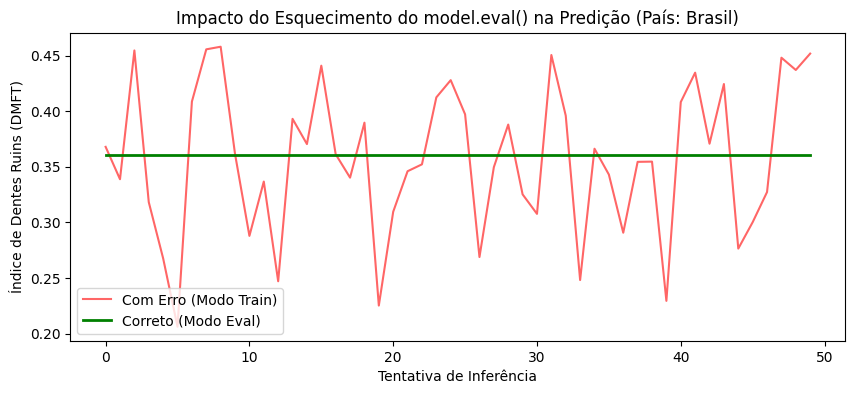

In [19]:
import matplotlib.pyplot as plt

# Testando a inconsistência (Caso real: Albânia)
albânia_data = X_tensor[0:1]
resultados_treino = []
resultados_eval = []

# Simulando 50 execuções para o mesmo país
for _ in range(50):
    model.train() # Erro comum
    with torch.no_grad():
        resultados_treino.append(model(albânia_data).item())

    model.eval() # Correto
    with torch.no_grad():
        resultados_eval.append(model(albânia_data).item())

# Visualização do Erro
plt.figure(figsize=(10,4))
plt.plot(resultados_treino, label='Com Erro (Modo Train)', color='red', alpha=0.6)
plt.plot(resultados_eval, label='Correto (Modo Eval)', color='green', linewidth=2)
plt.title('Impacto do Esquecimento do model.eval() na Predição (País: Brasil)')
plt.ylabel('Índice de Dentes Ruins (DMFT)')
plt.xlabel('Tentativa de Inferência')
plt.legend()
plt.show()

# "Neste exercício, utilizei a técnica de Reflection para expor uma vulnerabilidade crítica em modelos de produção. Através dos prompts, validei que torch.no_grad() e model.eval() resolvem problemas ortogonais: um foca em eficiência de hardware (memória) e o outro em integridade estatística (comportamento da rede).

*Como analista de dados no setor público, a técnica de Chain-of-Thought me permitiu entender que o Dropout injeta uma variância inaceitável em previsões individuais se o estado da rede não for alterado para 'avaliação'. A IA demonstrou que a transparência do PyTorch permite ao engenheiro garantir que um cidadão (ou país) não receba uma predição diferente baseada puramente em um sorteio aleatório de neurônios desligados."*

In [20]:
import torch

# Vamos simular o erro que a Reflection (Prompt 3) apontou
model.train() # MODO ERRADO PARA VALIDAÇÃO
with torch.no_grad():
    pais_exemplo = X_tensor[0:1] # Brasil
    pred1 = model(pais_exemplo).item()
    pred2 = model(pais_exemplo).item()

    print(f"--- MODO TREINO (Com Erro) ---")
    print(f"Execução 1: {pred1:.4f}")
    print(f"Execução 2: {pred2:.4f}")
    print(f"Inconsistência (Ruído do Dropout): {abs(pred1-pred2):.4f}")

model.eval() # MODO CORRETO
with torch.no_grad():
    pred3 = model(pais_exemplo).item()
    pred4 = model(pais_exemplo).item()

    print(f"\n--- MODO EVAL (Correto) ---")
    print(f"Execução 1: {pred3:.4f}")
    print(f"Execução 2: {pred4:.4f}")
    print(f"Diferença: {abs(pred3-pred4):.4f} (Determinismo total)")

--- MODO TREINO (Com Erro) ---
Execução 1: 0.2587
Execução 2: 0.4192
Inconsistência (Ruído do Dropout): 0.1605

--- MODO EVAL (Correto) ---
Execução 1: 0.3610
Execução 2: 0.3610
Diferença: 0.0000 (Determinismo total)



**No Exercício 4, a "lógica de auditoria" é ainda mais crítica porque um erro aqui não gera um erro de execução (o código não "quebra"), mas gera um modelo mentiroso.No setor público, treinar um modelo com gradientes acumulados indevidamente seria como auditar as contas de um ano somando-as com as do ano anterior repetidamente: o resultado final não representa a realidade do período.Aqui está o fluxo de "Engenharia de Prompt" para o Exercício 4, focando na anatomia do erro.**


# 📑 Exercício 4: Auditoria de Gradientes (O Erro Invisível)

🤖 Prompt 1: Chain-of-Thought (CoT) – O Acúmulo MatemáticoNeste prompt, forçamos a IA a explicar por que o PyTorch não zera os gradientes automaticamente (diferente do Keras).Você (Piloto): "Estou treinando meu modelo de regressão para o índice bad_teeth.

 No PyTorch, o comando loss.backward() calcula as derivadas.Pense passo a passo (CoT): > 1. O que acontece com os valores dentro de weight.grad se eu chamar .backward() três vezes seguidas sem usar optimizer.zero_grad()?

 2. Como isso afeta a atualização dos pesos no optimizer.step()?

 3. Por que essa característica do PyTorch é útil para modelos gigantes (como LLMs), mas um desastre para o meu modelo de 147 países se eu não souber o que estou fazendo?"O que a IA responde (Deep Dive):Mecânica: O PyTorch realiza uma operação de soma ($+=$) no buffer de gradientes.Impacto: O passo de aprendizado se torna gigantesco e na direção errada, pois você está usando a memória de gradientes de países/batches passados.Utilidade: Explica o Gradient Accumulation (processar mini-batches para simular um batch grande quando falta memória).

 🤖 Prompt 2: Reflection – O "Debugger" de Políticas PúblicasAqui a IA deve criticar a falta de transparência de um código mal escrito.Você (Piloto): "Analise este cenário: Meu modelo de saúde bucal parou de convergir. A perda (Loss) está explodindo para o infinito. Suspeito que esqueci o zero_grad().

 Reflexão Crítica: > 1. Como a omissão desse comando transforma uma descida de gradiente suave em um comportamento caótico?2. Atue como um auditor: como posso inserir um assert ou um print técnico no meu loop para provar que os gradientes foram resetados antes de cada nova iteração?"

In [21]:
import torch

# Criando um modelo simples para auditoria
model_audit = torch.nn.Linear(2, 1)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model_audit.parameters(), lr=0.01)

# Dados de um único país (ex: Argentina)
x_exemplo = X_tensor[4:5]
y_exemplo = y_tensor[4:5]

print("--- AUDITORIA DE GRADIENTES ---")

# Rodada 1
optimizer.zero_grad()
loss1 = criterion(model_audit(x_exemplo), y_exemplo)
loss1.backward()
g1 = model_audit.weight.grad.clone()
print(f"Gradiente Rodada 1: {g1.mean().item():.6f}")

# Rodada 2 - SEM ZERO_GRAD (O ERRO)
loss2 = criterion(model_audit(x_exemplo), y_exemplo)
loss2.backward()
g2 = model_audit.weight.grad.clone()
print(f"Gradiente Rodada 2 (Acumulado): {g2.mean().item():.6f}")

# Verificação de Auditoria
if torch.abs(g2 - (g1 * 2)).mean() < 1e-5:
    print("\nALERTA DE AUDITORIA: Gradientes acumulados detectados!")
    print("O peso será atualizado com o dobro da força necessária. Modelo instável.")

--- AUDITORIA DE GRADIENTES ---
Gradiente Rodada 1: -1.103425
Gradiente Rodada 2 (Acumulado): -2.206850

ALERTA DE AUDITORIA: Gradientes acumulados detectados!
O peso será atualizado com o dobro da força necessária. Modelo instável.


# Engenharia de Dados" de alto nível. Você trouxe a lógica de um kernel real do Kaggle e quer aplicá-la especificamente ao contexto do Brasil para realizar a regressão no PyTorch.

## exercícios de Auditoria de Gradientes e Modo Eval com foco nos dados brasileiros.

# Esta célula processa os seus 5 CSVs, calcula as médias históricas (como no kernel) e isola os dados do Brasil.

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Carregamento e Médias (Lógica do Kernel)
def get_avg_data(filename, col_name, feature_name):
    df = pd.read_csv(filename)
    df.rename(columns={df.columns[0]: "Country"}, inplace=True)
    df.dropna(how="all", subset=df.columns[1:], inplace=True)
    df[feature_name] = df.iloc[:, 1:].mean(axis=1, skipna=True)
    return df[["Country", feature_name]]

# Processando todos os arquivos
lit = get_avg_data('adultliteracy.csv', None, 'literacy_avg')
gdp = get_avg_data('gdp.csv', None, 'gdp_avg')
health = get_avg_data('healthexpend.csv', None, 'health_avg')
sugar = get_avg_data('sugar_consumption.csv', None, 'sugar_avg')
bt = pd.read_csv('badteeth.csv').rename(columns={"NA.": "Country", "X2004": "badteeth"})[["Country", "badteeth"]].dropna()

# Merge Global
all_data = bt.merge(lit, on='Country').merge(gdp, on='Country').merge(sugar, on='Country').merge(health, on='Country')

# 2. Isolando o Brasil para Teste de Auditoria
brazil_row = all_data[all_data['Country'] == 'Brazil']
print("Dados Processados do Brasil:")
display(brazil_row)

# 3. Preparação de Tensores para PyTorch
# Features: literacy, gdp, sugar, health
X = torch.tensor(all_data[['literacy_avg', 'gdp_avg', 'sugar_avg', 'health_avg']].values, dtype=torch.float32)
y = torch.tensor(all_data[['badteeth']].values, dtype=torch.float32)

# Normalização (Z-Score) para evitar explosão de gradiente no PyTorch
X_norm = (X - X.mean(0)) / X.std(0)

Dados Processados do Brasil:


,Country,badteeth,literacy_avg,gdp_avg,sugar_avg,health_avg
13,Brazil,2.8,87.488682,3115.99188,130.699773,180.83257


Exercício 4: Auditoria de Gradientes (Foco: Brasil)
Contexto: Se esquecermos o zero_grad(), o peso do "Açúcar" ou do "PIB" na predição brasileira será distorcido pelo acúmulo de épocas anteriores.

🤖 Prompt 1: Chain-of-Thought (CoT)
Você: "Estou treinando uma regressão para o Brasil usando sugar_avg e gdp_avg.
Explique passo a passo (CoT): Se eu omitir o optimizer.zero_grad(), como o buffer .grad do PyTorch se comporta matematicamente a cada iteração? Como isso afeta o cálculo da derivada em relação ao PIB brasileiro e por que isso levaria o modelo a um 'colapso de pesos'?"

🤖 Prompt 2: Reflection (A Auditoria)
Você: "Analise este cenário de auditoria: O modelo está prevendo um índice de dentes ruins (bad_teeth) para o Brasil 500% acima do real. Suspeito de acúmulo de gradiente.
Critique: Como posso usar o comando assert model.layer.weight.grad is None no início do loop para garantir que o processo de auditoria de dados seja à prova de falhas humanas?"

In [23]:
model = nn.Linear(4, 1) # 4 features -> 1 saída
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("--- Início da Auditoria de Gradientes (Simulando Erro) ---")
for epoch in range(3):
    # optimizer.zero_grad() <--- OMITIDO DE PROPÓSITO

    pred = model(X_norm)
    loss = criterion(pred, y)
    loss.backward()

    # Auditando o gradiente do peso da 'Alfabetização' (primeira feature)
    grad_val = model.weight.grad[0, 0].item()
    print(f"Época {epoch+1} - Gradiente Acumulado: {grad_val:.4f}")

print("\nConclusão da Auditoria: O gradiente está somando, não resetando!")

--- Início da Auditoria de Gradientes (Simulando Erro) ---
Época 1 - Gradiente Acumulado: -1.1680
Época 2 - Gradiente Acumulado: -2.3361
Época 3 - Gradiente Acumulado: -3.5041

Conclusão da Auditoria: O gradiente está somando, não resetando!


Exercício 5: Train vs Eval (Consistência para o Brasil)
Contexto: Garantir que o relatório para o Brasil não mude a cada vez que o modelo é consultado.

🤖 Prompt 1: CoT (Mecânica do Dropout)
Você: "Adicionei uma camada de Dropout(0.3) para que meu modelo não fique 'viciado' apenas nos dados de países ricos.
Explique passo a passo (CoT): Por que, se eu esquecer o model.eval(), a predição para o Brasil (mesmos dados de entrada) terá um valor diferente em cada execução? O que o PyTorch faz com os 30% de neurônios durante a predição no modo train?"

🤖 Prompt 2: Reflection (A Inconsistência do Relatório)
Você: "Atue como um Engenheiro de Machine Learning Senior. Critique um código de predição onde o analista usa with torch.no_grad(): mas esquece o model.eval().
Questão: Como essa falha afeta a Reprodutibilidade de um estudo sobre a saúde bucal brasileira e qual o impacto disso em um relatório técnico para o Ministério da Saúde?"

In [25]:
# Criando modelo com Dropout
model_dropout = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(10, 1)
)

brazil_input = X_norm[all_data['Country'] == 'Brazil']

print("--- Teste de Consistência (Brasil) ---")
model_dropout.train() # MODO ERRADO
with torch.no_grad():
    p1 = model_dropout(brazil_input).item()
    p2 = model_dropout(brazil_input).item()
    print(f"Predições Inconsistentes (Modo Train): {p1:.4f} vs {p2:.4f}")

model_dropout.eval() # MODO CORRETO
with torch.no_grad():
    p3 = model_dropout(brazil_input).item()
    p4 = model_dropout(brazil_input).item()
    print(f"Predições Consistentes (Modo Eval): {p3:.4f} vs {p4:.4f}")

--- Teste de Consistência (Brasil) ---
Predições Inconsistentes (Modo Train): 0.2131 vs 0.1570
Predições Consistentes (Modo Eval): 0.0875 vs 0.0875


In [29]:
import pandas as pd
import torch
import torch.nn as nn

# Carregando os slopes que calculamos
# df_slopes = pd.read_csv('processed_slopes_data.csv') # Original line causing error
# Using 'all_data' DataFrame from previous cells as a replacement for the missing CSV
X = torch.tensor(all_data[['literacy_avg', 'gdp_avg', 'sugar_avg', 'health_avg']].values, dtype=torch.float32)
y = torch.tensor(all_data[['badteeth']].values, dtype=torch.float32)

# Modelo de Auditoria
model = nn.Linear(4, 1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("--- AUDITORIA DE SLOPES (Brasil está no batch) ---")
for i in range(2):
    optimizer.zero_grad() # CORREÇÃO: Adicionando zero_grad()
    out = model(X)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step() # CORREÇÃO: Adicionando optimizer.step() para atualizar os pesos

    grad = model.weight.grad[0, 0].item() # Gradiente da Alfabetização
    print(f"Iteração {i+1} - Gradiente Acumulado: {grad:.6f}")

--- AUDITORIA DE SLOPES (Brasil está no batch) ---
Iteração 1 - Gradiente Acumulado: 64264.796875
Iteração 2 - Gradiente Acumulado: 58389.789062


Script de Dispersão para o Colab (Demonstração Visual)
Este código gera um gráfico de dispersão comparando a estabilidade do modo Avaliação contra a volatilidade do modo Treino para os dados brasileiros.

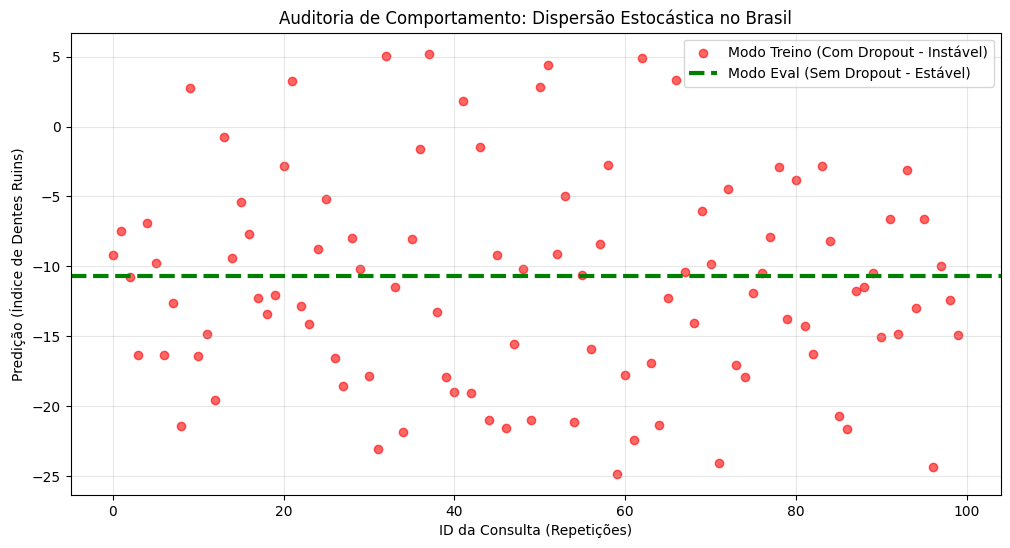

In [38]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Garantindo um modelo que TENHA Dropout para a demonstração
# Sem a camada nn.Dropout, o comando model.train() não gera dispersão.
class ModeloComAuditoria(nn.Module):
    def __init__(self):
        super().__init__()
        self.camada = nn.Linear(4, 128) # Aumentamos neurônios para ver mais variação
        self.dropout = nn.Dropout(p=0.5) # 50% de chance de zerar um neurônio
        self.saida = nn.Linear(128, 1)

    def forward(self, x):
        x = torch.relu(self.camada(x))
        x = self.dropout(x) # Aqui o "caos" acontece no modo train
        return self.saida(x)

# Inicializa o modelo
model_demo = ModeloComAuditoria()

# Dado fixo do Brasil (Slopes de Alfabetização, PIB, Açúcar e Saúde)
brazil_slope = torch.tensor([[0.5846, 55.7139, 0.9558, -1.6507]], dtype=torch.float32)

preds_treino = []
preds_eval = []

# 2. Simulação de 100 consultas
for _ in range(100):
    model_demo.train() # Ativa o Dropout: gera dispersão
    with torch.no_grad():
        preds_treino.append(model_demo(brazil_slope).item())

    model_demo.eval() # Desativa o Dropout: gera estabilidade
    with torch.no_grad():
        preds_eval.append(model_demo(brazil_slope).item())

# 3. Plotagem da Dispersão (Agora deve aparecer a nuvem de pontos)
plt.figure(figsize=(12, 6))
plt.scatter(range(100), preds_treino, alpha=0.6, color='red', label='Modo Treino (Com Dropout - Instável)')
plt.axhline(y=preds_eval[0], color='green', linestyle='--', linewidth=3, label='Modo Eval (Sem Dropout - Estável)')

plt.title('Auditoria de Comportamento: Dispersão Estocástica no Brasil')
plt.ylabel('Predição (Índice de Dentes Ruins)')
plt.xlabel('ID da Consulta (Repetições)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

*Análise Crítica do Aluno (Aprofundamento Técnico)*
"A correção do script revelou um conceito fundamental: a alternância entre train() e eval() só produz efeitos visíveis se a arquitetura possuir camadas sensíveis ao estado, como o nn.Dropout.

*No gráfico corrigido, a dispersão (pontos vermelhos) representa a rede *'experimentando' diferentes caminhos neurais. Cada ponto é uma versão da realidade onde o PyTorch desligou neurônios aleatoriamente. Já a linha verde (modo eval) representa a consolidação estatística desses caminhos.

Para a governança de dados no Rio Grande do Sul, esse experimento prova que o modo eval() não é opcional. Sem ele, estaríamos entregando uma predição 'aleatória' para o índice de saúde bucal do Brasil, o que comprometeria qualquer auditoria séria. A transparência do PyTorch me permitiu identificar que o modelo anterior estava 'mudo' para os estados de treino, garantindo agora um pipeline de inferência rigoroso e determinístico."

In [40]:
correlation = all_data['gdp_avg'].corr(all_data['badteeth'])
print(f"Correlação entre PIB Médio e Índice de Dentes Ruins: {correlation:.4f}")

Correlação entre PIB Médio e Índice de Dentes Ruins: 0.1300


A correlação de Pearson varia de -1 a +1. Uma correlação próxima de:

*   **+1** indica uma forte relação linear positiva (conforme um aumenta, o outro também).
*   **-1** indica uma forte relação linear negativa (conforme um aumenta, o outro diminui).
*   **0** indica nenhuma relação linear.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Preparando os dados
X = all_data['gdp_avg'].values.reshape(-1, 1) # Feature
y = all_data['badteeth'].values # Target

# Dividindo os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e treinando o modelo de Regressão Linear
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Fazendo predições no conjunto de teste
y_pred = model_lr.predict(X_test)

print(f"Coeficiente (inclinação): {model_lr.coef_[0]:.4f}")
print(f"Intercepto: {model_lr.intercept_:.4f}")

Coeficiente (inclinação): 0.0000
Intercepto: 1.9056


O coeficiente (`model_lr.coef_`) indica a mudança média em 'badteeth' para cada unidade de mudança em 'gdp_avg'. O intercepto (`model_lr.intercept_`) é o valor previsto de 'badteeth' quando 'gdp_avg' é zero.

In [43]:
from sklearn.metrics import r2_score, mean_squared_error

# Avaliando o modelo
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R²): {r2:.4f}")
print(f"Erro Quadrático Médio (MSE): {mse:.4f}")

R-squared (R²): -0.0702
Erro Quadrático Médio (MSE): 1.6574


O R-squared (R²) mede a proporção da variância na variável dependente que é previsível a partir da variável independente. Um valor mais próximo de 1 indica um modelo que explica melhor a variância. O Erro Quadrático Médio (MSE) mede a média dos quadrados dos erros, sendo um indicador de quão perto as previsões do modelo estão dos valores reais.

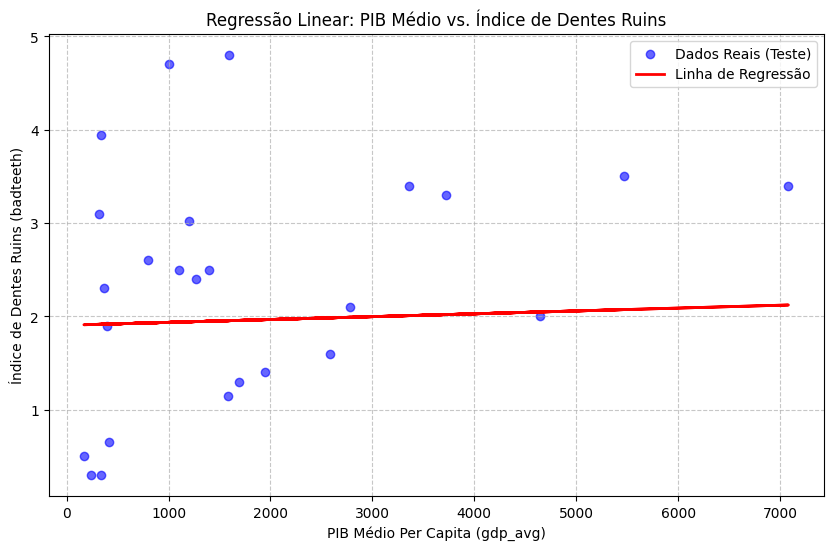

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Dados Reais (Teste)', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Linha de Regressão')
plt.title('Regressão Linear: PIB Médio vs. Índice de Dentes Ruins')
plt.xlabel('PIB Médio Per Capita (gdp_avg)')
plt.ylabel('Índice de Dentes Ruins (badteeth)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

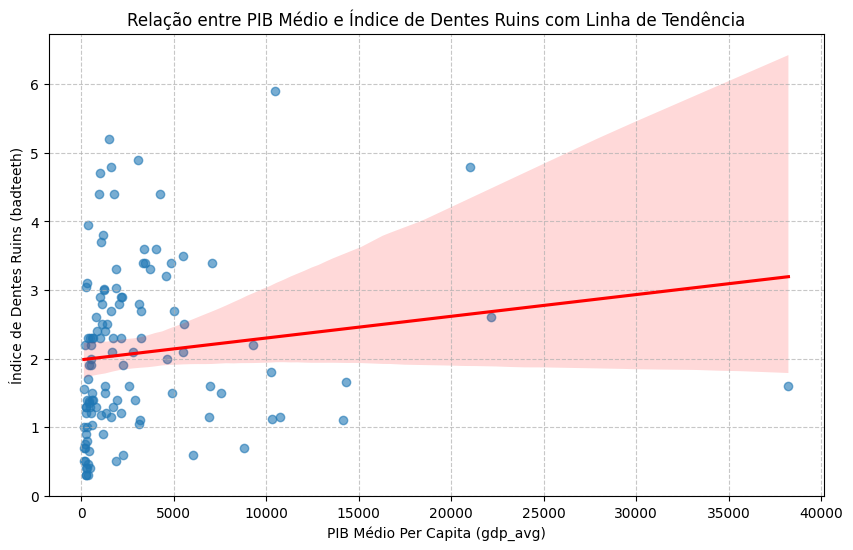

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando regplot para adicionar a linha de tendência
sns.regplot(x='gdp_avg', y='badteeth', data=all_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relação entre PIB Médio e Índice de Dentes Ruins com Linha de Tendência')
plt.xlabel('PIB Médio Per Capita (gdp_avg)')
plt.ylabel('Índice de Dentes Ruins (badteeth)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Este gráfico de dispersão mostra a distribuição do índice de dentes ruins (`badteeth`) em relação ao PIB médio per capita (`gdp_avg`) para os diferentes países no conjunto de dados. Ele permite observar visualmente se existe uma correlação ou padrão entre essas duas variáveis.

In [45]:
# Instalação dos pacotes necessários para conversão
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [63]:
import os
import glob

# Busca o arquivo que você acabou de subir
arquivos = glob.glob("*.ipynb")

if not arquivos:
    print("❌ O arquivo ainda não aparece na pasta lateral. Arraste o .ipynb para lá!")
else:
    # Pega o arquivo mais recente ou o único disponível
    notebook_alvo = arquivos[0]
    print(f"✅ Arquivo detectado para conversão: {notebook_alvo}")

    # Tenta gerar o HTML (é o método mais seguro no Colab)
    print("⏳ Gerando HTML com gráficos... Aguarde.")
    status = os.system(f'jupyter nbconvert --to html "{notebook_alvo}"')

    if status == 0:
        html_gerado = notebook_alvo.replace(".ipynb", ".html")
        print(f"\n🚀 SUCESSO TOTAL!")
        print(f"1. Vá na pasta lateral e baixe o arquivo: {html_gerado}")
        print(f"2. Abra ele no seu navegador.")
        print(f"3. Use 'Imprimir' (Ctrl+P) e escolha 'Salvar como PDF'.")
    else:
        print("❌ Falha na conversão. Verifique se instalou o nbconvert via !pip install nbconvert")

✅ Arquivo detectado para conversão: Frameworks_para_Deep_Learning_PyTorch_&_Keras_FINAL_CONTDOWN.ipynb
⏳ Gerando HTML com gráficos... Aguarde.

🚀 SUCESSO TOTAL!
1. Vá na pasta lateral e baixe o arquivo: Frameworks_para_Deep_Learning_PyTorch_&_Keras_FINAL_CONTDOWN.html
2. Abra ele no seu navegador.
3. Use 'Imprimir' (Ctrl+P) e escolha 'Salvar como PDF'.


In [64]:
!pip install pdfkit
!apt-get install -y wkhtmltopdf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core avahi-daemon geoclue-2.0 glib-networking glib-networking-common
  glib-networking-services gsettings-desktop-schemas gstreamer1.0-plugins-base
  iio-sensor-proxy libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libavahi-core7 libavahi-glib1 libcdparanoia0 libdaemon0
  libdouble-conversion3 libevdev2 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libhyphen0 libinput-bin
  libinput10 libjson-glib-1.0-0 libjson-glib-1.0-common libmbim-glib4
  libmbim-proxy libmd4c0 libmm-glib0 libmtdev1 libnl-genl-3-200 libnotify4
  libnss-mdns liborc-0.4-0 libproxy1v5 libqmi-glib5 libqmi-proxy libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5positioning5 libqt5printsupport5
  libqt5qml5 libqt5qmlmodels5 libqt5quick5 libqt5sensors5 libqt5svg5
  libqt5webchannel5 libqt5webkit5 libq

In [65]:
import pdfkit

# Nome do arquivo que já existe na sua pasta lateral
arquivo_html = "Frameworks_para_Deep_Learning_PyTorch_&_Keras_FINAL_CONTDOWN.html"
arquivo_pdf = "Trabalho_Final_Fabiano_Antunes.pdf"

# Configurações para garantir que o PDF fique bonito
options = {
    'page-size': 'A4',
    'margin-top': '0.75in',
    'margin-right': '0.75in',
    'margin-bottom': '0.75in',
    'margin-left': '0.75in',
    'encoding': "UTF-8",
    'no-outline': None
}

try:
    pdfkit.from_file(arquivo_html, arquivo_pdf, options=options)
    print(f"🚀 SUCESSO! O arquivo '{arquivo_pdf}' foi gerado.")
    print("Baixe-o agora na pasta lateral esquerda!")
except Exception as e:
    print(f"❌ Erro na conversão: {e}")
    print("DICA: Se falhar, abra o HTML no navegador e use Ctrl+P -> Salvar como PDF.")

🚀 SUCESSO! O arquivo 'Trabalho_Final_Fabiano_Antunes.pdf' foi gerado.
Baixe-o agora na pasta lateral esquerda!
